In [13]:
# Machine Learning Internship Project
## Restaurant Data Analysis
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset  (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")  # notice space if present
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Data Preprocessing

In [6]:
# BASIC INFO
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

# CHECK MISSING VALUES
print("\nMissing Values:\n", df.isnull().sum())

# DROP MISSING VALUES (fast method)
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

# ENCODE CATEGORICAL COLUMNS
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
# FINAL CHECK
print("\nAfter preprocessing:")
print(df.head())
print("\nRemaining Missing Values:\n", df.isnull().sum())

Shape of dataset: (9551, 21)

Columns:
 Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Missing Values:
 Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes            

TASK 1: Rating Prediction

MSE: 1.1201694876761883
R2 Score: 0.5108498967311826


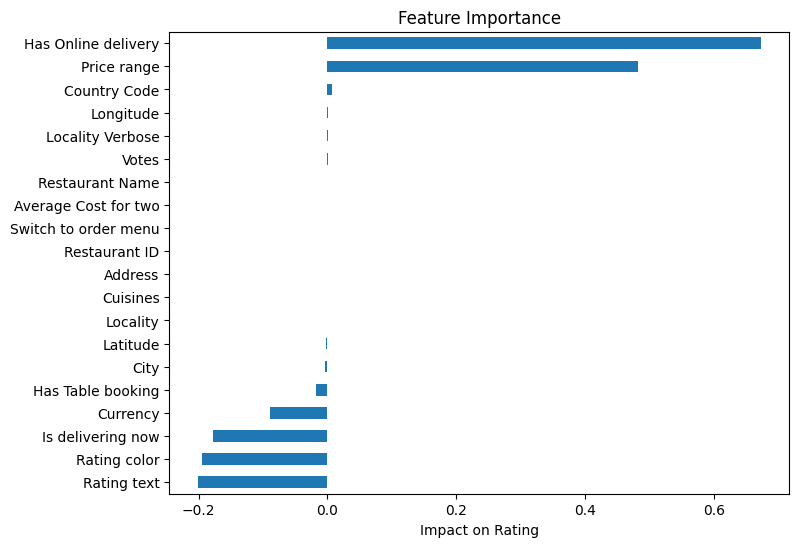

In [8]:
# SPLIT FEATURES & TARGET
from sklearn.model_selection import train_test_split

X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TRAIN MODEL
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# PREDICTIONS
y_pred = model.predict(X_test)

# EVALUATION
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.xlabel("Impact on Rating")
plt.show()

### Insights:
- Model achieved R² score of 0.51
- Price range and online delivery strongly affect ratings
- Model shows moderate prediction capability

TASK 3: CUISINE CLASSIFICATION

Accuracy: 0.17234154007333682


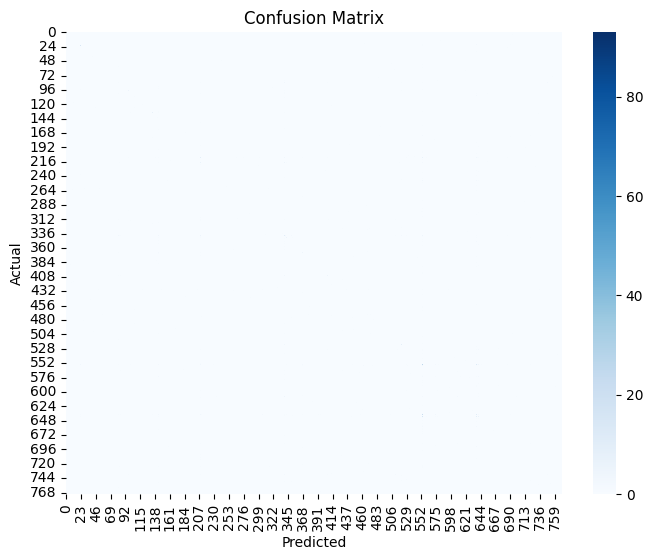

In [9]:
# SPLIT FEATURES & TARGET
from sklearn.model_selection import train_test_split

X = df.drop("Cuisines", axis=1)
y = df["Cuisines"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TRAIN MODEL
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# PREDICTIONS
y_pred = model.predict(X_test)

# EVALUATION
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Insights:
- Model achieved ~17% accuracy
- Classification is difficult due to many cuisine categories
- Model tends to predict frequent cuisines more accurately

TASK 4: Location Analysis

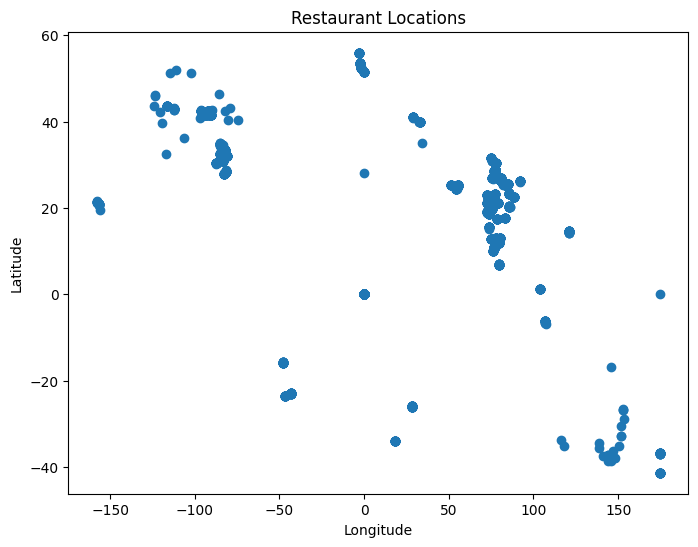

In [10]:
import matplotlib.pyplot as plt

# Scatter plot of locations
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'])

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [11]:
#City-Wise analysis
city_ratings = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)

print(city_ratings.head(10))

City
56     4.900000
106    4.800000
73     4.650000
94     4.633333
75     4.625000
15     4.600000
67     4.535000
122    4.525000
66     4.500000
121    4.500000
Name: Aggregate rating, dtype: float64


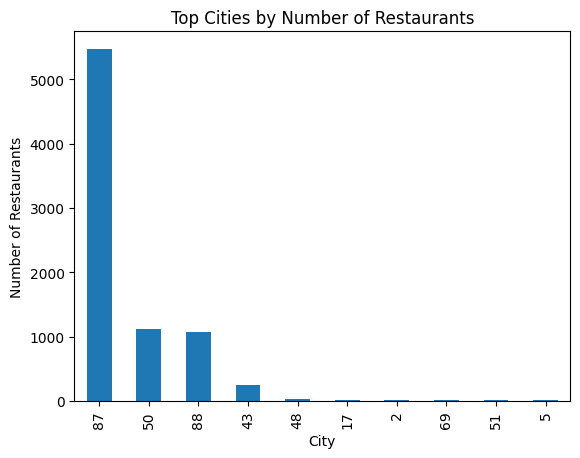

In [12]:
city_counts = df["City"].value_counts().head(10)

city_counts.plot(kind='bar')

plt.title("Top Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.show()

### Insights:
- Restaurants are unevenly distributed geographically
- Some cities have higher average ratings
- High-density cities indicate strong competition